In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

In [61]:
df_fake = pd.read_csv(r"C:\Users\Shahin Parween\OneDrive\Desktop\Fake News Detection\Fake.csv")
df_true = pd.read_csv(r"C:\Users\Shahin Parween\OneDrive\Desktop\Fake News Detection\True.csv")

In [62]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [63]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [64]:
df_fake['class'] = 0
df_true['class'] = 1

In [65]:
df_fake.shape, df_true.shape

((23481, 5), (21417, 5))

# Removing last 10 rows for manual testing

In [66]:
df_fake_manual_testing = df_fake.tail(10).copy()
df_fake = df_fake.head(len(df_fake) - 10).copy()

df_true_manual_testing = df_true.tail(10).copy()
df_true = df_true.head(len(df_true) - 10).copy()


In [67]:
df_fake.shape, df_true.shape

((23471, 5), (21407, 5))

In [68]:
df_fake_manual_testing["class"] = 0
df_true_manual_testing["class"] = 1

In [69]:
df_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [70]:
df_true_manual_testing.head(10)

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [71]:
df_manual_testing = pd.concat([df_fake_manual_testing,df_true_manual_testing], axis = 0)
df_manual_testing.to_csv("manual_testing.csv")

In [72]:
df_merge = pd.concat([df_fake, df_true], axis =0 )
df_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [73]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [74]:
df = df_merge.drop(["title", "subject","date"], axis = 1)

In [75]:
df.isnull().sum()

text     0
class    0
dtype: int64

In [76]:
df = df.sample(frac = 1)

In [77]:
df.head()

,text,class
17491,"This morning, President Trump tweeted a note o...",0
6374,"While it s not nice to criticize people, per s...",0
3910,In a sorry attempt to smear the protester who ...,0
2663,WASHINGTON (Reuters) - Republicans will consid...,1
15934,LONDON (Reuters) - Foreign minister Boris John...,1


In [78]:
df.reset_index(inplace = True)
df.drop(["index"], axis = 1, inplace = True)

In [79]:
df.columns

Index(['text', 'class'], dtype='object')

In [80]:
df.head()

,text,class
0,"This morning, President Trump tweeted a note o...",0
1,"While it s not nice to criticize people, per s...",0
2,In a sorry attempt to smear the protester who ...,0
3,WASHINGTON (Reuters) - Republicans will consid...,1
4,LONDON (Reuters) - Foreign minister Boris John...,1


# Creating a function to process the texts

In [81]:
def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text) 
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)    
    return text

In [82]:
df["text"] = df["text"].apply(wordopt)

# Defining dependent and independent variable


In [83]:
x =df["text"]
y = df["class"]

# Splitting Training and Testing data

In [84]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.25)

# Converting text into vectors

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [92]:
from sklearn.naive_bayes import MultinomialNB

NB = MultinomialNB()
NB.fit(xv_train, y_train)
pred_nb = NB.predict(xv_test)
print("NB Score:", NB.score(xv_test, y_test))
print(classification_report(y_test, pred_nb))

NB Score: 0.9353832442067737
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5946
           1       0.94      0.92      0.93      5274

    accuracy                           0.94     11220
   macro avg       0.94      0.93      0.94     11220
weighted avg       0.94      0.94      0.94     11220



In [93]:
from sklearn.svm import LinearSVC

SVM = LinearSVC()
SVM.fit(xv_train, y_train)
pred_svm = SVM.predict(xv_test)
print("SVM Score:", SVM.score(xv_test, y_test))
print(classification_report(y_test, pred_svm))

SVM Score: 0.9946524064171123
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5946
           1       1.00      0.99      0.99      5274

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



In [94]:
def output_label(n):
    return "Fake News" if n == 0 else "Not A Fake News"

def manual_testing(news):
    testing_news = {"text": [news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_xv_test = vectorization.transform(new_def_test["text"])

    pred_NB  = NB.predict(new_xv_test)
    pred_SVM = SVM.predict(new_xv_test)

    print("\nNB Prediction:  {}".format(output_label(pred_NB[0])))
    print("SVM Prediction: {}".format(output_label(pred_SVM[0])))

news = str(input())
manual_testing(news)

 1



NB Prediction:  Fake News
SVM Prediction: Fake News


# Bar chart comparing NB vs SVM accuracy

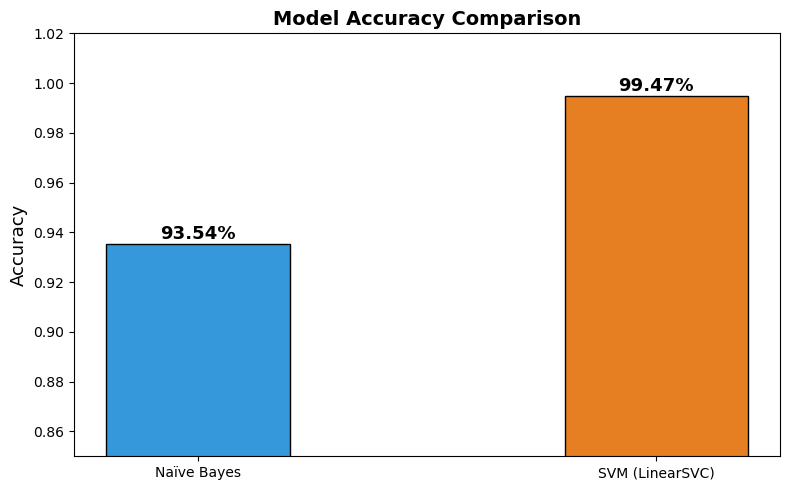

In [104]:
import matplotlib.pyplot as plt

models = ['Naïve Bayes', 'SVM (LinearSVC)']
scores = [NB.score(xv_test, y_test), SVM.score(xv_test, y_test)]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['#3498db', '#e67e22'], edgecolor='black', width=0.4)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score*100:.2f}%', ha='center', fontsize=13, fontweight='bold')

plt.ylim(0.85, 1.02)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion matrix showing true/false positives

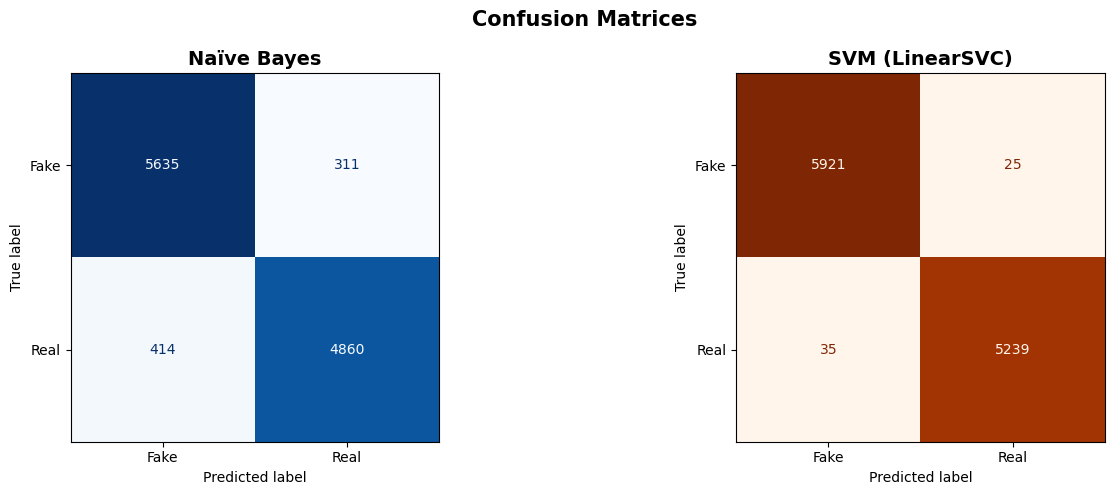

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title, cmap in [
    (axes[0], pred_nb,  'Naïve Bayes',     'Blues'),
    (axes[1], pred_svm, 'SVM (LinearSVC)', 'Oranges')
]:
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Fake', 'Real']).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Which words most indicate Fake vs Real news

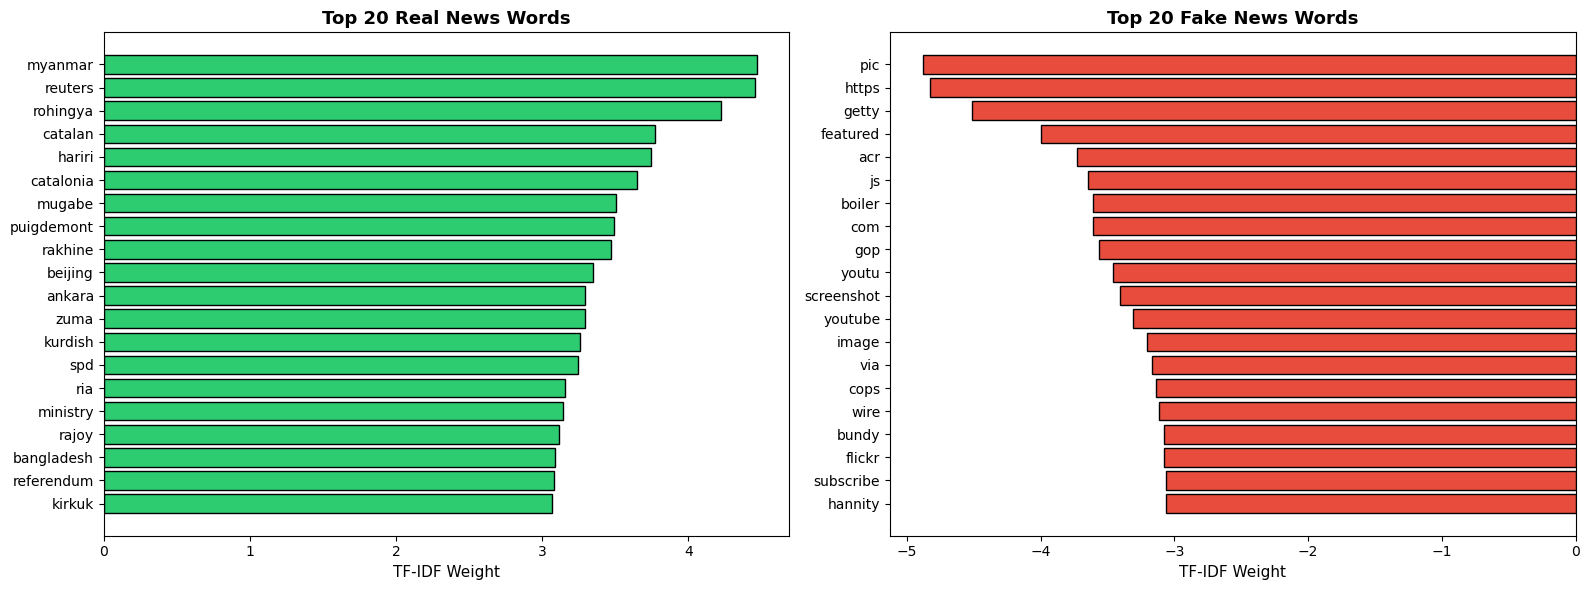

In [106]:
feature_names = vectorization.get_feature_names_out()
nb_scores = NB.feature_log_prob_[1] - NB.feature_log_prob_[0]

top_real = nb_scores.argsort()[-20:][::-1]
top_fake = nb_scores.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, indices, label, color in [
    (axes[0], top_real, 'Real News Words', '#2ecc71'),
    (axes[1], top_fake, 'Fake News Words', '#e74c3c')
]:
    ax.barh(feature_names[indices][::-1], nb_scores[indices][::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 20 {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('TF-IDF Weight', fontsize=11)

plt.tight_layout()
plt.show()

# Test any custom news article 

In [107]:
def output_label(n):
    return "Fake News" if n == 0 else "Not A Fake News"

def manual_testing(news):
    testing_news = {"text": [news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_xv_test = vectorization.transform(new_def_test["text"])

    pred_NB  = NB.predict(new_xv_test)
    pred_SVM = SVM.predict(new_xv_test)

    print("\nNB Prediction:  {}".format(output_label(pred_NB[0])))
    print("SVM Prediction: {}".format(output_label(pred_SVM[0])))

news = str(input("Enter news text: "))
manual_testing(news)

Enter news text:  11



NB Prediction:  Fake News
SVM Prediction: Fake News
